In [ ]:
import numpy as np
import numpy as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
path="/content/house_prices.csv"
pd.read_csv(path)

,HouseID,Location,Bedrooms,Bathrooms,SquareFeet,Price
0,1,Chicago,1,2,1928,266294
1,2,Chicago,2,1,1093,83082
2,3,New York,3,1,2100,431828
3,4,Chicago,4,2,2456,85311
4,5,Los Angeles,4,2,1524,267251
...,...,...,...,...,...,...
995,996,New York,3,2,2528,253692
996,997,Los Angeles,1,2,563,113057
997,998,New York,1,1,793,387508
998,999,Los Angeles,4,2,625,85333


In [ ]:
df=pd.read_csv(path)
print(df.head())

   HouseID     Location  Bedrooms  Bathrooms  SquareFeet   Price
0        1      Chicago         1          2        1928  266294
1        2      Chicago         2          1        1093   83082
2        3     New York         3          1        2100  431828
3        4      Chicago         4          2        2456   85311
4        5  Los Angeles         4          2        1524  267251


In [ ]:
df.dtypes

,0
HouseID,int64
Location,object
Bedrooms,int64
Bathrooms,int64
SquareFeet,int64
Price,int64


In [ ]:
df.describe()

,HouseID,Bedrooms,Bathrooms,SquareFeet,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2.495000,1.525000,1743.524000,281536.431000
std,288.819436,1.105983,0.499624,725.252486,132390.173003
min,1.000000,1.000000,1.000000,501.000000,50267.000000
25%,250.750000,2.000000,1.000000,1102.500000,165854.750000
50%,500.500000,2.000000,2.000000,1727.000000,290911.500000
75%,750.250000,3.000000,2.000000,2370.250000,397076.500000
max,1000.000000,4.000000,2.000000,2999.000000,499890.000000


In [ ]:
print(df.isnull().sum())

HouseID       0
Location      0
Bedrooms      0
Bathrooms     0
SquareFeet    0
Price         0
dtype: int64


In [ ]:
print(df.head())

   HouseID     Location  Bedrooms  Bathrooms  SquareFeet   Price
0        1      Chicago         1          2        1928  266294
1        2      Chicago         2          1        1093   83082
2        3     New York         3          1        2100  431828
3        4      Chicago         4          2        2456   85311
4        5  Los Angeles         4          2        1524  267251


In [ ]:
print(df.columns.tolist())

['HouseID', 'Location', 'Bedrooms', 'Bathrooms', 'SquareFeet', 'Price']


In [ ]:
from sklearn.model_selection import train_test_split
# x = input features, y = what we want to predict
x = df.drop(columns=['Price'])
y = df['Price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Training rows :",x_train.shape[0])
print("Testing  rows :",x_test.shape[0])

Training rows : 800
Testing  rows : 200


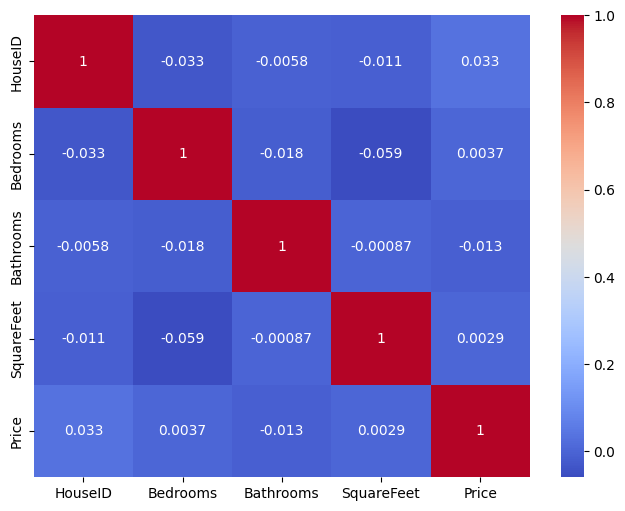

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Location'] = le.fit_transform(df['Location'])

print(df.head())

   HouseID  Location  Bedrooms  Bathrooms  SquareFeet   Price
0        1         0         1          2        1928  266294
1        2         0         2          1        1093   83082
2        3         3         3          1        2100  431828
3        4         0         4          2        2456   85311
4        5         2         4          2        1524  267251


In [24]:
X = df.drop(columns=['Price'])
y = df['Price']


In [25]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

predictions = model.predict(x_test)

In [27]:
df_encoded = pd.get_dummies(df, columns=['Location'], drop_first=True)

X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

In [28]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(x_train, y_train)

predictions = model.predict(x_test)

In [29]:
print(df.dtypes)

HouseID       int64
Location      int64
Bedrooms      int64
Bathrooms     int64
SquareFeet    int64
Price         int64
dtype: object
